# Sentiment-Driven Reinforcement Learning Trader  
This notebook walks through the full pipeline of the project:
- Fetch financial news data
- Fetch stock price data
- Compute sentiment scores using VADER
- Merge sentiment with prices
- Visualize the data before prediction and trading

In [4]:
import os
import sys

# --- Make parent folder (SENTIMENT_RL_TRADER) visible to Python ---
project_root = os.path.abspath("..")   # one level up from the notebook folder
if project_root not in sys.path:
    sys.path.append(project_root)

# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_fetcher import fetch_news, fetch_stock_history, align_news_with_stock
from sentiment_model import add_sentiment



In [8]:
news_df = fetch_news("AAPL")
news_df.head()


,title,description,publishedAt
0,3 ASX ETFs I'd buy right now to build wealth,Here's why these funds could be destined to de...,2025-12-04T23:00:00Z
1,Elevation Lab、CR2032コイン電池の代わりに単4電池2本でAirTagを最大...,Elevation LabがCR2032コイン電池の代わりに単4電池2本でAirTagを最大...,2025-12-04T22:53:51Z
2,Live Nasdaq Composite: Markets Hunt Direction ...,Live Updates\n Wall Street Analyst Calls \n 50...,2025-12-04T15:48:00Z
3,Here’s Why Apple (AAPL) is on the Detectors Li...,"Brown Advisory, an investment management compa...",2025-12-04T13:45:28Z
4,Here’s Why Apple (AAPL) is on the Detectors Li...,"Brown Advisory, an investment management compa...",2025-12-04T13:32:59Z


In [9]:
# Fetch financial news for a company, e.g., Apple
# Remove non-English headlines (keep only those with ASCII characters)
news_df = news_df[news_df["title"].str.encode('ascii', 'ignore').str.decode('ascii') == news_df["title"]]

news_df.head(10)


# Show the first 10 rows to confirm structure
news_df.head(10)


,title,description,publishedAt
0,3 ASX ETFs I'd buy right now to build wealth,Here's why these funds could be destined to de...,2025-12-04T23:00:00Z
2,Live Nasdaq Composite: Markets Hunt Direction ...,Live Updates\n Wall Street Analyst Calls \n 50...,2025-12-04T15:48:00Z
5,Apple (AAPL) Price Target Raised as Loop Capit...,Apple Inc. (NASDAQ:AAPL) is one of the AI Stoc...,2025-12-04T09:15:51Z
6,"Pressure Points: Apple AI's SVP, John Giannand...",Good news for AAPL investors: Apple has a new ...,2025-12-04T07:15:04Z
13,5 Things to Know Before the Stock Market Opens,"News of the day for Dec. 3, 2025",2025-12-03T13:46:09Z
14,Apple's leadership shift marks a 'major reset'...,Apple's late-to-the-party AI strategy has its ...,2025-12-03T11:00:31Z
15,Apple (AAPL) Gains Analyst Confidence as iPhon...,Apple Inc. (NASDAQ:AAPL) is one of the Buzzing...,2025-12-03T09:50:54Z
16,Purpose Investments Inc. Announces 2025 Estima...,"TORONTO, Dec. 02, 2025 (GLOBE NEWSWIRE) -- Pur...",2025-12-03T02:26:00Z
18,S&P 500 Gains and Losses Today: Boeing Climbs ...,"An aerospace giant got a lift on Tuesday, Dec....",2025-12-02T22:17:52Z
19,Apple shares hit new all-time intraday and clo...,"In Nasdaq trading today, shares of Apple Inc. ...",2025-12-02T21:17:20Z


In [10]:
# Fetch AAPL stock history based on the config settings (period + interval)
stock_df = fetch_stock_history("AAPL")

stock_df.head()

,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2025-11-06 14:30:00+00:00,267.890015,272.820007,267.890015,272.820007,6762187,0.0,0.0
1,2025-11-06 15:30:00+00:00,272.828003,273.399994,271.550110,272.181488,5580072,0.0,0.0
2,2025-11-06 16:30:00+00:00,272.179993,272.220001,270.390015,271.424988,3198033,0.0,0.0
3,2025-11-06 17:30:00+00:00,271.420013,272.469788,270.920013,271.350006,2621839,0.0,0.0
4,2025-11-06 18:30:00+00:00,271.369995,272.160004,271.020386,271.990112,1783486,0.0,0.0


In [11]:
# Align timestamps so each news article gets paired with the nearest stock price
merged_df = align_news_with_stock(news_df, stock_df)

merged_df.head(10)


,title,description,publishedAt,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,Earnings live: Zoom stock pops after upbeat re...,The third quarter earnings season has been mos...,2025-11-24 21:30:15+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0
1,Stocks Finish Sharply Higher as Tech Stocks Soar,The S&P 500 Index ($SPX ) (SPY ) on Monday clo...,2025-11-24 21:35:37+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0
2,Apple shares hit new all-time closing high,"In Nasdaq trading today, shares of Apple Inc. ...",2025-11-24 21:41:03+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0
3,Cuts Jobs in Sales Division,,2025-11-25 07:15:11+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0
4,Is Apple Stock Outperforming the Dow?,Apple stock has outperformed the Dow Jones ove...,2025-11-25 10:23:02+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0
5,"Earnings live: Kohl's, Abercrombie stocks soar...",The third quarter earnings season has been mos...,2025-11-25 13:15:54+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0
6,Opinion: Apple Has a Good Shot to Outperform a...,Quick Read\n \n \n Apple (AAPL) pays just $1B ...,2025-11-25 13:59:16+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0
7,Warren Buffett's Berkshire Hathaway Bet on Thi...,Berkshire Hathaway purchased 17.8 million shar...,2025-11-25 16:24:06+00:00,2025-11-25 16:30:00+00:00,277.820007,279.309998,277.500000,279.070099,2504679,0.0,0.0
8,"This Morning, Wall Street is Bullish on AMAT, ...","Quick Read\n \n \n Just this morning, UBS upgr...",2025-11-25 16:25:08+00:00,2025-11-25 16:30:00+00:00,277.820007,279.309998,277.500000,279.070099,2504679,0.0,0.0
9,"This Morning, Wall Street is Bullish on AMAT, ...","Quick Read\n-\nJust this morning, UBS upgraded...",2025-11-25 16:58:49+00:00,2025-11-25 16:30:00+00:00,277.820007,279.309998,277.500000,279.070099,2504679,0.0,0.0


In [12]:
# Apply VADER sentiment analysis to each news title
merged_df = add_sentiment(merged_df)

# Show the headline, timestamp, sentiment score, and stock close price
merged_df[["publishedAt", "title", "sentiment", "Close"]].head(10)


,publishedAt,title,sentiment,Close
0,2025-11-24 21:30:15+00:00,Earnings live: Zoom stock pops after upbeat re...,-0.0258,275.980011
1,2025-11-24 21:35:37+00:00,Stocks Finish Sharply Higher as Tech Stocks Soar,0.0000,275.980011
2,2025-11-24 21:41:03+00:00,Apple shares hit new all-time closing high,0.2960,275.980011
3,2025-11-25 07:15:11+00:00,Cuts Jobs in Sales Division,-0.2960,278.904999
4,2025-11-25 10:23:02+00:00,Is Apple Stock Outperforming the Dow?,0.0000,278.904999
5,2025-11-25 13:15:54+00:00,"Earnings live: Kohl's, Abercrombie stocks soar...",0.0000,278.904999
6,2025-11-25 13:59:16+00:00,Opinion: Apple Has a Good Shot to Outperform a...,0.4404,278.904999
7,2025-11-25 16:24:06+00:00,Warren Buffett's Berkshire Hathaway Bet on Thi...,0.0000,279.070099
8,2025-11-25 16:25:08+00:00,"This Morning, Wall Street is Bullish on AMAT, ...",0.0000,279.070099
9,2025-11-25 16:58:49+00:00,"This Morning, Wall Street is Bullish on AMAT, ...",0.0000,279.070099


In [13]:
merged_df.to_csv("../merged_news_stock_sentiment.csv", index=False)


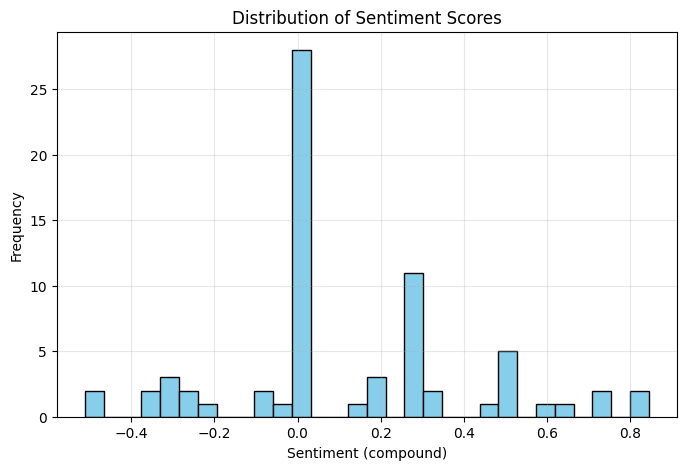

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(merged_df["sentiment"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment (compound)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


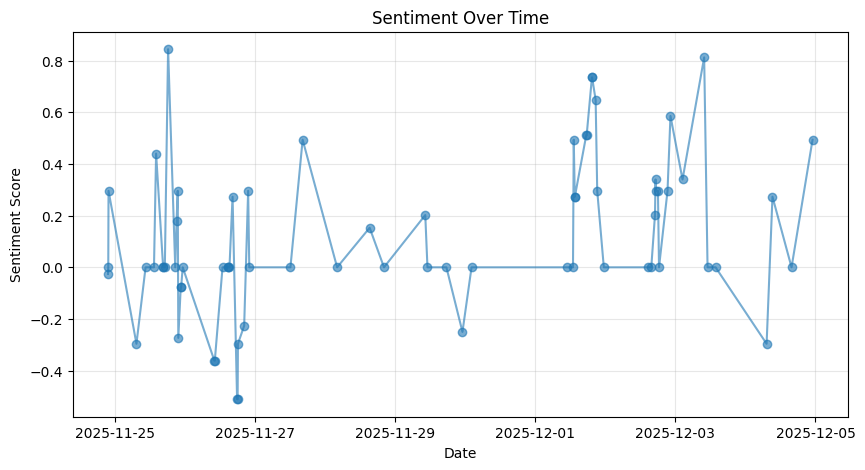

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(merged_df["publishedAt"], merged_df["sentiment"], marker="o", linestyle="-", alpha=0.6)
plt.title("Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.grid(alpha=0.3)
plt.show()


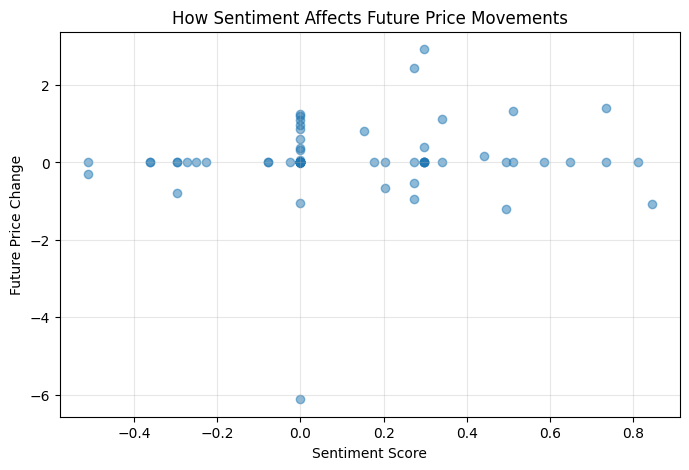

In [13]:

merged_df = merged_df.sort_values("publishedAt")


merged_df["future_return"] = merged_df["Close"].shift(-1) - merged_df["Close"]


plt.figure(figsize=(8, 5))
plt.scatter(merged_df["sentiment"], merged_df["future_return"], alpha=0.5)
plt.title("How Sentiment Affects Future Price Movements")
plt.xlabel("Sentiment Score")
plt.ylabel("Future Price Change")
plt.grid(alpha=0.3)
plt.show()
